In [1]:
spark

# Libraries

In [6]:
# !pip install spark-nlp==5.1.3

In [19]:
# !pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.2/539.2 kB 9.7 MB/s eta 0:00:00


In [155]:
# !pip install transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 18.0 MB/s eta 0:00:00MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 10.8 MB/s eta 0:00:00m eta 0:00:010:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 20.1 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 20.3 MB/s eta 0:00:00 MB/s eta 0:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 21.7 MB/s eta 0:00:000:00:010:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 16.0 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 18.4 MB/s eta 0:00:00m eta 0:00:010:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 20.6 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.3 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd
import string
from functools import reduce

from pyspark.sql import functions as F
from pyspark.sql.types import StringType

from sparknlp.base import DocumentAssembler, Finisher
from sparknlp.annotator import Tokenizer, Normalizer, StopWordsCleaner, LemmatizerModel
from pyspark.ml import Pipeline

import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
import torch

In [4]:
pd.set_option('display.max_colwidth', None)

In [5]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/hduser/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/hduser/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [7]:
DATABASE_NAME ='s2ca2'

STOCK_TABLE_NAME ='stock_prices'
TWEETS_TABLE_NAME ='stock_tweets'
STOCK_SENTIMENT_TABLE_NAME='stock_sentiment'

STOCK_PATH = "/home/hduser/Desktop/CA/data/stockprice/"
TWEETS_PATH = "/home/hduser/Desktop/CA/data/stocktweet/"
SENTIMENT_TWEETS_PATH = "/home/hduser/Desktop/CA/data/sentiment_tweet"
STOCK_SENTIMENT_PATH = "/home/hduser/Desktop/CA/data/stock_sentiment"

MONGO_CONNECTION = "mongodb://localhost:27017/"
MYSQL_CONNECTION = "jdbc:mysql://localhost:3306/"

# MySQL
MYSQL_USER = "root"
MYSQL_PASSWORD = "password"

# Raw Data Ingestion

## Load stock

In [8]:
df_csv_raw_stock = spark.read.option("header", True).csv('file://'+STOCK_PATH)

In [9]:
df_csv_raw_stock = df_csv_raw_stock.withColumn(
    "ticker",
    F.regexp_extract(F.input_file_name(), r"([^/]+)\.csv$", 1)
)

In [10]:
df_csv_raw_stock.show(5, truncate=False)

+----------+------------------+-----------------+------------------+------------------+------------------+--------+------+
|Date      |Open              |High             |Low               |Close             |Adj Close         |Volume  |ticker|
+----------+------------------+-----------------+------------------+------------------+------------------+--------+------+
|2019-12-31|36.80265808105469 |37.191650390625  |36.72675323486328 |37.17267608642578 |31.371051788330078|15175703|PFE   |
|2020-01-02|37.286529541015625|37.33396530151367|36.88804626464844 |37.13472366333008 |31.339025497436523|16514072|PFE   |
|2020-01-03|36.736244201660156|37.2296028137207 |36.688804626464844|36.93548583984375 |31.170879364013672|14922848|PFE   |
|2020-01-06|36.831119537353516|37.00189971923828|36.71726989746094 |36.88804626464844 |31.13084602355957 |15771951|PFE   |
|2020-01-07|37.11574935913086 |37.12523651123047|36.69829177856445 |36.764705657958984|31.026758193969727|20108107|PFE   |
+----------+----

In [11]:
df_csv_raw_stock.printSchema()

root
 |-- Date: string (nullable = true)
 |-- Open: string (nullable = true)
 |-- High: string (nullable = true)
 |-- Low: string (nullable = true)
 |-- Close: string (nullable = true)
 |-- Adj Close: string (nullable = true)
 |-- Volume: string (nullable = true)
 |-- ticker: string (nullable = false)



In [12]:
df_csv_raw_stock = df_csv_raw_stock.selectExpr(
    "ticker",
    "to_date(Date, 'yyyy-MM-dd') as date",
    "cast(Open as double) as open",
    "cast(High as double) as high",
    "cast(Low as double) as low",
    "cast(Close as double) as close",
    "cast(`Adj Close` as double) as adj_close",
    "cast(Volume as bigint) as volume"
)

In [13]:
df_csv_raw_stock.printSchema()

root
 |-- ticker: string (nullable = false)
 |-- date: date (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- adj_close: double (nullable = true)
 |-- volume: long (nullable = true)



In [14]:
# Cassandra
df_csv_raw_stock.write \
    .format("org.apache.spark.sql.cassandra") \
    .mode("overwrite") \
    .options(table=STOCK_TABLE_NAME, keyspace=DATABASE_NAME) \
    .option("confirm.truncate", "true") \
    .save()

In [15]:
df_cassandra_raw_stock = spark.read \
  .format("org.apache.spark.sql.cassandra") \
  .options(table=STOCK_TABLE_NAME, keyspace=DATABASE_NAME) \
  .load()

In [16]:
df_cassandra_raw_stock.show(5)

+------+----------+------------------+------------------+------------------+------------------+------------------+-------+
|ticker|      date|         adj_close|             close|              high|               low|              open| volume|
+------+----------+------------------+------------------+------------------+------------------+------------------+-------+
|   MCD|2019-12-31|180.27401733398438|197.61000061035156| 197.9499969482422|196.55999755859375| 196.8000030517578|2278700|
|   MCD|2020-01-02|183.17506408691406| 200.7899932861328| 200.8000030517578|197.80999755859375|             198.0|3554200|
|   MCD|2020-01-03|      182.52734375| 200.0800018310547| 200.5500030517578|198.85000610351562|199.38999938964844|2767600|
|   MCD|2020-01-06| 184.5799560546875| 202.3300018310547|202.77000427246094|199.35000610351562|199.60000610351562|4660400|
|   MCD|2020-01-07|184.85365295410156| 202.6300048828125|202.67999267578125|200.50999450683594| 201.8699951171875|4047400|
+------+--------

In [17]:
# Mongo
URI=MONGO_CONNECTION + DATABASE_NAME + '.' + STOCK_TABLE_NAME
df_csv_raw_stock.write \
    .format("mongo") \
    .mode("overwrite") \
    .option("uri",URI) \
    .save()

In [18]:
df_mongo_raw_stock = spark.read \
  .format("mongo") \
  .option("uri",URI) \
  .load()

In [19]:
df_mongo_raw_stock.show(5)

+--------------------+-----------------+-----------------+-------------------+-----------------+-----------------+-----------------+-------+----------+
|                 _id|        adj_close|            close|               date|             high|              low|             open| ticker|    volume|
+--------------------+-----------------+-----------------+-------------------+-----------------+-----------------+-----------------+-------+----------+
|{680d2688d985ab29...|3230.780029296875|3230.780029296875|2019-12-31 00:00:00|3231.719970703125|3212.030029296875|3215.179931640625|%5EGSPC|2894760000|
|{680d2688d985ab29...| 3257.85009765625| 3257.85009765625|2020-01-02 00:00:00|3258.139892578125|3235.530029296875|   3244.669921875|%5EGSPC|3459930000|
|{680d2688d985ab29...| 3234.85009765625| 3234.85009765625|2020-01-03 00:00:00| 3246.14990234375|3222.340087890625|3226.360107421875|%5EGSPC|3484700000|
|{680d2688d985ab29...|3246.280029296875|3246.280029296875|2020-01-06 00:00:00|3246.84008

In [20]:
df_csv_raw_stock.write \
    .format("jdbc") \
    .mode("overwrite") \
    .option("url", MYSQL_CONNECTION+DATABASE_NAME) \
    .option("dbtable", STOCK_TABLE_NAME) \
    .option("user", MYSQL_USER) \
    .option("password", MYSQL_PASSWORD) \
    .option("driver", "com.mysql.cj.jdbc.Driver") \
    .save()

In [21]:
df_db_raw_stock = spark.read \
    .format("jdbc") \
    .option("url", MYSQL_CONNECTION+DATABASE_NAME) \
    .option("dbtable", STOCK_TABLE_NAME) \
    .option("user", MYSQL_USER) \
    .option("password", MYSQL_PASSWORD) \
    .option("driver", "com.mysql.cj.jdbc.Driver") \
    .load()

In [22]:
df_db_raw_stock.show(5)

+------+----------+------------------+-----------------+------------------+------------------+------------------+--------+
|ticker|      date|              open|             high|               low|             close|         adj_close|  volume|
+------+----------+------------------+-----------------+------------------+------------------+------------------+--------+
|   PFE|2019-12-31| 36.80265808105469|  37.191650390625| 36.72675323486328| 37.17267608642578|31.371051788330078|15175703|
|   PFE|2020-01-02|37.286529541015625|37.33396530151367| 36.88804626464844| 37.13472366333008|31.339025497436523|16514072|
|   PFE|2020-01-03|36.736244201660156| 37.2296028137207|36.688804626464844| 36.93548583984375|31.170879364013672|14922848|
|   PFE|2020-01-06|36.831119537353516|37.00189971923828| 36.71726989746094| 36.88804626464844| 31.13084602355957|15771951|
|   PFE|2020-01-07| 37.11574935913086|37.12523651123047| 36.69829177856445|36.764705657958984|31.026758193969727|20108107|
+------+--------

## Load tweets

In [23]:
df_csv_raw_tweets = spark.read \
    .option("header", True) \
    .option("multiLine", True) \
    .option("escape", "\"") \
    .csv('file://'+TWEETS_PATH)

In [24]:
df_csv_raw_tweets.show(5, truncate=False)

+------+----------+------+-------------------------------------------------------------------------------------------------------------------------------------------+
|id    |date      |ticker|tweet                                                                                                                                      |
+------+----------+------+-------------------------------------------------------------------------------------------------------------------------------------------+
|100001|01/01/2020|AMZN  |$AMZN Dow futures up by 100 points already 🥳                                                                                              |
|100002|01/01/2020|TSLA  |$TSLA Daddy's drinkin' eArly tonight! Here's to a PT of ohhhhh $1000 in 2020! 🍻                                                           |
|100003|01/01/2020|AAPL  |$AAPL We’ll been riding since last December from $172.12 what to do. Decisions decisions hmm 🤔. I have 20 mins to decide. Any suggestions?|
|

In [25]:
df_csv_raw_tweets.printSchema()

root
 |-- id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- ticker: string (nullable = true)
 |-- tweet: string (nullable = true)



In [26]:
df_csv_raw_tweets = df_csv_raw_tweets.selectExpr(
    "cast(id as bigint) as id",
    "ticker",
    "to_date(date, 'dd/MM/yyyy') as date",
    "tweet"
)

In [27]:
df_csv_raw_tweets.printSchema()

root
 |-- id: long (nullable = true)
 |-- ticker: string (nullable = true)
 |-- date: date (nullable = true)
 |-- tweet: string (nullable = true)



In [28]:
# Cassandra
df_csv_raw_tweets.write \
    .format("org.apache.spark.sql.cassandra") \
    .mode("append") \
    .options(table=TWEETS_TABLE_NAME, keyspace=DATABASE_NAME) \
    .option("confirm.truncate", "true") \
    .save()

In [29]:
df_cassandra_raw_tweets = spark.read \
  .format("org.apache.spark.sql.cassandra") \
  .options(table=TWEETS_TABLE_NAME, keyspace=DATABASE_NAME) \
  .load()

In [30]:
df_cassandra_raw_tweets.show(5, truncate=False)

+------+------+----------+--------------------------------------------------------------------------------------------+
|ticker|id    |date      |tweet                                                                                       |
+------+------+----------+--------------------------------------------------------------------------------------------+
|SBUX  |100095|2020-01-09|$SBUX following through nicely as shown in yesterday’s tweets. 👍💪🙏🤑                     |
|SBUX  |100100|2020-01-09|$SBUX I drink enough coffee, I’m investing 💪🏼                                             |
|SBUX  |100175|2020-01-15|$SBUX TPO alot of volume at 91.74, thats after a strong run up...🤔                         |
|SBUX  |100299|2020-01-24|$SBUX \n\nLiterally everything in my portfolio has been hitting 52 week highs except this 😂|
|SBUX  |100344|2020-01-28|$SBUX this earnings release was as exciting as decaffeinated cold brew.\n💤 💤💤😴          |
+------+------+----------+--------------------------

In [31]:
# Mongo
URI=MONGO_CONNECTION + DATABASE_NAME + '.' + TWEETS_TABLE_NAME
df_csv_raw_tweets.write \
    .format("mongo") \
    .mode("overwrite") \
    .option("uri",URI) \
    .save()

In [32]:
df_mongo_raw_tweets = spark.read \
  .format("mongo") \
  .option("uri",URI) \
  .load()

In [33]:
df_mongo_raw_tweets.show(5, truncate=False)

+--------------------------+-------------------+------+------+-------------------------------------------------------------------------------------------------------------------------------------------+
|_id                       |date               |id    |ticker|tweet                                                                                                                                      |
+--------------------------+-------------------+------+------+-------------------------------------------------------------------------------------------------------------------------------------------+
|{680d26a2d985ab2941dea2d1}|2020-01-01 00:00:00|100001|AMZN  |$AMZN Dow futures up by 100 points already 🥳                                                                                              |
|{680d26a2d985ab2941dea2d2}|2020-01-01 00:00:00|100002|TSLA  |$TSLA Daddy's drinkin' eArly tonight! Here's to a PT of ohhhhh $1000 in 2020! 🍻                                                

In [34]:
# MySQL
df_csv_raw_tweets.write \
    .format("jdbc") \
    .mode("overwrite") \
    .option("url", MYSQL_CONNECTION+DATABASE_NAME) \
    .option("dbtable", TWEETS_TABLE_NAME) \
    .option("user", MYSQL_USER) \
    .option("password", MYSQL_PASSWORD) \
    .option("driver", "com.mysql.cj.jdbc.Driver") \
    .save()

In [35]:
df_db_raw_tweets = spark.read \
    .format("jdbc") \
    .option("url", MYSQL_CONNECTION+DATABASE_NAME) \
    .option("dbtable", TWEETS_TABLE_NAME) \
    .option("user", MYSQL_USER) \
    .option("password", MYSQL_PASSWORD) \
    .option("driver", "com.mysql.cj.jdbc.Driver") \
    .load()

In [36]:
df_db_raw_tweets.show(5, truncate=False)

+------+------+----------+-------------------------------------------------------------------------------------------------------------------------------------------+
|id    |ticker|date      |tweet                                                                                                                                      |
+------+------+----------+-------------------------------------------------------------------------------------------------------------------------------------------+
|100001|AMZN  |2020-01-01|$AMZN Dow futures up by 100 points already 🥳                                                                                              |
|100002|TSLA  |2020-01-01|$TSLA Daddy's drinkin' eArly tonight! Here's to a PT of ohhhhh $1000 in 2020! 🍻                                                           |
|100003|AAPL  |2020-01-01|$AAPL We’ll been riding since last December from $172.12 what to do. Decisions decisions hmm 🤔. I have 20 mins to decide. Any suggestions?|
|

## Verify consistency

### Count

In [37]:
all_counts = {
    "stock_prices": {
        "CSV": df_csv_raw_stock.count(),
        "MongoDB": df_mongo_raw_stock.count(),
        "Cassandra": df_cassandra_raw_stock.count(),
        "MySQL": df_db_raw_stock.count()
    },
    "stock_tweets": {
        "CSV": df_csv_raw_tweets.count(),
        "MongoDB": df_mongo_raw_tweets.count(),
        "Cassandra": df_cassandra_raw_tweets.count(),
        "MySQL": df_db_raw_tweets.count()
    }
}

df_total_counts = pd.DataFrame(all_counts).T

In [38]:
display(df_total_counts)

,CSV,MongoDB,Cassandra,MySQL
stock_prices,10175,10175,10175,10175
stock_tweets,10000,10000,10000,10000


### Nulls

In [39]:
def get_null_counts(spark_df):
    return {col: spark_df.filter(f"{col} IS NULL").count() for col in spark_df.columns}

stock_dataframes = {
    "CSV (stock)": df_csv_raw_stock,
    "MongoDB (stock)": df_mongo_raw_stock,
    "Cassandra (stock)": df_cassandra_raw_stock,
    "MySQL (stock)": df_db_raw_stock,
}

tweet_dataframes = {
    "CSV (tweets)": df_csv_raw_tweets,
    "MongoDB (tweets)": df_mongo_raw_tweets,
    "Cassandra (tweets)": df_cassandra_raw_tweets,
    "MySQL (tweets)": df_db_raw_tweets,
}

stock_nulls = {}
for name, df in stock_dataframes.items():
    stock_nulls[name] = {col: df.filter(f"{col} IS NULL").count() for col in df.columns}
df_stock_nulls = pd.DataFrame(stock_nulls)

tweet_nulls = {}
for name, df in tweet_dataframes.items():
    tweet_nulls[name] = {col: df.filter(f"{col} IS NULL").count() for col in df.columns}
df_tweet_nulls = pd.DataFrame(tweet_nulls)

In [40]:
display(df_stock_nulls)

,CSV (stock),MongoDB (stock),Cassandra (stock),MySQL (stock)
ticker,0.0,0,0.0,0.0
date,0.0,0,0.0,0.0
open,0.0,0,0.0,0.0
high,0.0,0,0.0,0.0
low,0.0,0,0.0,0.0
close,0.0,0,0.0,0.0
adj_close,0.0,0,0.0,0.0
volume,0.0,0,0.0,0.0
_id,NaN,0,NaN,NaN


In [41]:
display(df_tweet_nulls)

,CSV (tweets),MongoDB (tweets),Cassandra (tweets),MySQL (tweets)
id,0.0,0,0.0,0.0
ticker,0.0,0,0.0,0.0
date,0.0,0,0.0,0.0
tweet,0.0,0,0.0,0.0
_id,NaN,0,NaN,NaN


# Distributed Preprocessing

In [42]:
URI=MONGO_CONNECTION + DATABASE_NAME + '.' + TWEETS_TABLE_NAME
df_mongo_raw_tweets = spark.read \
  .format("mongo") \
  .option("uri",URI) \
  .load()

In [43]:
df_mongo_raw_tweets.select("tweet").show(5, truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------+
|tweet                                                                                                                                      |
+-------------------------------------------------------------------------------------------------------------------------------------------+
|$AMZN Dow futures up by 100 points already 🥳                                                                                              |
|$TSLA Daddy's drinkin' eArly tonight! Here's to a PT of ohhhhh $1000 in 2020! 🍻                                                           |
|$AAPL We’ll been riding since last December from $172.12 what to do. Decisions decisions hmm 🤔. I have 20 mins to decide. Any suggestions?|
|$TSLA happy new year, 2020, everyone🍷🎉🙏                                                                                                 |
|$TSLA haha 

In [44]:
df_db_raw_stock = spark.read \
    .format("jdbc") \
    .option("url", MYSQL_CONNECTION+DATABASE_NAME) \
    .option("dbtable", STOCK_TABLE_NAME) \
    .option("user", MYSQL_USER) \
    .option("password", MYSQL_PASSWORD) \
    .option("driver", "com.mysql.cj.jdbc.Driver") \
    .load()

In [45]:
df_db_raw_stock.show(5, truncate=False)

+------+----------+------------------+-----------------+------------------+------------------+------------------+--------+
|ticker|date      |open              |high             |low               |close             |adj_close         |volume  |
+------+----------+------------------+-----------------+------------------+------------------+------------------+--------+
|PFE   |2019-12-31|36.80265808105469 |37.191650390625  |36.72675323486328 |37.17267608642578 |31.371051788330078|15175703|
|PFE   |2020-01-02|37.286529541015625|37.33396530151367|36.88804626464844 |37.13472366333008 |31.339025497436523|16514072|
|PFE   |2020-01-03|36.736244201660156|37.2296028137207 |36.688804626464844|36.93548583984375 |31.170879364013672|14922848|
|PFE   |2020-01-06|36.831119537353516|37.00189971923828|36.71726989746094 |36.88804626464844 |31.13084602355957 |15771951|
|PFE   |2020-01-07|37.11574935913086 |37.12523651123047|36.69829177856445 |36.764705657958984|31.026758193969727|20108107|
+------+--------

## Regex pre‑clean step

In [46]:
REGEX_RULES = [
    (r"\n", " "),                             # Replace newlines with space
    (r"http\S+|www\S+|https\S+", " "),        # Remove URLs
    (r"\$[A-Za-z]+", " "),                    # Remove $TICKERS
    (r"@\w+", " "),                           # Remove mentions
    (r"#[A-Za-z0-9_]+", " "),                 # Remove hashtags
    (r"\b\d+[a-zA-Z]+\b", " "),               # Remove number-letter combos (e.g. 135C)
    (r"([a-zA-Z])\1{2,}", r"$1"),             # Reduce repeated characters (e.g., ohhhhh -> oh)
    (r"[^\w\s]", " "),                        # Remove punctuation/emojis
    (r"\s{2,}", " "),                         # Collapse multiple spaces
    (r"(?i)\b(rt|via)\b", " ")                # Remove retweet/quote markers (optional)
]

def clean_text(df, input_col="tweet", output_col="tweet_clean"):
    """
    Vectorised text pre‑cleaning with a single withColumn call.
    """

    cleaned = df.withColumn(
        output_col,
        F.trim(
            reduce(
                lambda col, rule: F.regexp_replace(col, rule[0], rule[1]),
                REGEX_RULES,
                F.col(input_col)
            )
        )
    )
    return cleaned

df_clean_tweets  = clean_text(df_mongo_raw_tweets)

In [47]:
df_clean_tweets.select(["tweet", "tweet_clean"]).limit(5).toPandas()

,tweet,tweet_clean
0,$AMZN Dow futures up by 100 points already 🥳,Dow futures up by 100 points already
1,$TSLA Daddy's drinkin' eArly tonight! Here's to a PT of ohhhhh $1000 in 2020! 🍻,Daddy s drinkin eArly tonight Here s to a PT of oh 1000 in 2020
2,$AAPL We’ll been riding since last December from $172.12 what to do. Decisions decisions hmm 🤔. I have 20 mins to decide. Any suggestions?,We ll been riding since last December from 172 12 what to do Decisions decisions hmm I have 20 mins to decide Any suggestions
3,"$TSLA happy new year, 2020, everyone🍷🎉🙏",happy new year 2020 everyone
4,"$TSLA haha just a collection of greats...""Mars"" rofl 😈😎🌠⏫🔮💸👏💪🚀🎆🎇📣🎉🎊 *bork*",haha just a collection of greats Mars rofl bork


## Spark NLP pipeline

In [48]:
default_sw = stopwords.words('english')

custom_sw = [w for w in default_sw if w not in {"up", "down"}]

custom_sw += [
    "di", "aapl", "tsla", "amzn", "dis",   
    "pt", "la", "ll", "ve", "re", "rh"
]
custom_sw += list(string.ascii_lowercase)

In [49]:
nlp_stages = [
    DocumentAssembler().setInputCol("tweet_clean").setOutputCol("document"),
    Tokenizer().setInputCols(["document"]).setOutputCol("token"),
    Normalizer().setInputCols(["token"]).setOutputCol("normalized").setLowercase(True),
    StopWordsCleaner().setInputCols(["normalized"]).setOutputCol("cleanTokens").setStopWords(custom_sw).setCaseSensitive(False),
    LemmatizerModel.pretrained().setInputCols(["cleanTokens"]).setOutputCol("lemma"),
    Finisher().setInputCols(["lemma"]).setOutputCols(["final_tokens"]).setCleanAnnotations(True)
]

nlp_pipeline = Pipeline(stages=nlp_stages)
df_clean_tweets  = nlp_pipeline.fit(df_clean_tweets).transform(df_clean_tweets)

lemma_antbnc download started this may take some time.
Approximate size to download 907.6 KB
[ / ]lemma_antbnc download started this may take some time.
Approximate size to download 907.6 KB
[ — ]Download done! Loading the resource.
[OK!]


In [50]:
df_clean_tweets = df_clean_tweets.withColumn(
    "final_tokens",
    F.array_distinct(F.col("final_tokens"))
)

In [51]:
df_clean_tweets.select(["tweet", "tweet_clean", "final_tokens"]).limit(10).toPandas()

,tweet,tweet_clean,final_tokens
0,$AMZN Dow futures up by 100 points already 🥳,Dow futures up by 100 points already,"[dow, future, up, point, already]"
1,$TSLA Daddy's drinkin' eArly tonight! Here's to a PT of ohhhhh $1000 in 2020! 🍻,Daddy s drinkin eArly tonight Here s to a PT of oh 1000 in 2020,"[daddy, drinkin, early, tonight, oh]"
2,$AAPL We’ll been riding since last December from $172.12 what to do. Decisions decisions hmm 🤔. I have 20 mins to decide. Any suggestions?,We ll been riding since last December from 172 12 what to do Decisions decisions hmm I have 20 mins to decide Any suggestions,"[ride, since, last, december, decision, hmm, min, decide, suggestion]"
3,"$TSLA happy new year, 2020, everyone🍷🎉🙏",happy new year 2020 everyone,"[happy, new, year, everyone]"
4,"$TSLA haha just a collection of greats...""Mars"" rofl 😈😎🌠⏫🔮💸👏💪🚀🎆🎇📣🎉🎊 *bork*",haha just a collection of greats Mars rofl bork,"[haha, collection, great, mar, rofl, bork]"
5,$TSLA NOBODY: Gas cars driven by humans killed 1000s upon 1000s in 2019.\n\nTesla shorts: OMG DID YOU HEAR 2 PEOPLE DIED FROM A TESLA CRASH😱,NOBODY Gas cars driven by humans killed upon in 2019 Tesla shorts OMG DID YOU HEAR 2 PEOPLE DIED FROM A TESLA CRASH,"[nobody, gas, car, drive, human, kill, upon, tesla, shorts, omg, hear, people, die, crash]"
6,$AAPL $300 calls First trade of 2020 Congrats to all bulls 😈,300 calls First trade of 2020 Congrats to all bulls,"[call, first, trade, congrats, bull]"
7,"$AAPL Remember, if you short every day, one of those days you will be right 😏",Remember if you short every day one of those days you will be right,"[remember, short, every, day, one, right]"
8,"$AAPL called it, the bear comment below makes me chuckle inside. So sweeet 😜",called it the bear comment below makes me chuckle inside So swet,"[call, bear, comment, make, chuckle, inside, swet]"
9,$HD Bought more at today's low. She is turning. Stars aligned.🤞,Bought more at today s low She is turning Stars aligned,"[buy, today, low, turn, star, align]"


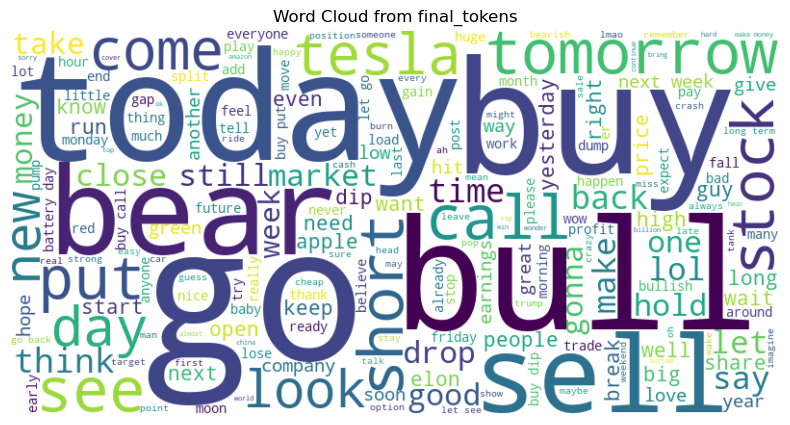

In [52]:
token_lists = df_clean_tweets.select("final_tokens").rdd.flatMap(lambda row: row).collect()

all_tokens = [token for sublist in token_lists for token in sublist if token]

text = ' '.join(all_tokens)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from final_tokens')
plt.show()

# Sentiment Analysis

## VADER polarity

In [53]:
df_vader = df_clean_tweets \
    .withColumn("final_tokens", F.concat_ws(" ", "final_tokens")) \
    .select(["ticker", "date", "tweet", "tweet_clean","final_tokens"]) 

In [54]:
df_vader.printSchema()

root
 |-- ticker: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- tweet: string (nullable = true)
 |-- tweet_clean: string (nullable = true)
 |-- final_tokens: string (nullable = false)



In [55]:
sent = SentimentIntensityAnalyzer()

@F.udf("string")
def vader_label(text):
    s = sent.polarity_scores(text)["compound"]
    return s
    
df_vader = df_vader.withColumn("sentiment", vader_label("tweet"))
df_vader = df_vader.withColumn("sentiment_clean", vader_label("tweet_clean"))
df_vader = df_vader.withColumn("sentiment_final", vader_label("final_tokens"))

In [56]:
df_vader.select(["tweet", "tweet_clean","final_tokens","sentiment","sentiment_clean","sentiment_final"]).limit(10).toPandas()

,tweet,tweet_clean,final_tokens,sentiment,sentiment_clean,sentiment_final
0,$AMZN Dow futures up by 100 points already 🥳,Dow futures up by 100 points already,dow future up point already,0.0,0.0,0.0
1,$TSLA Daddy's drinkin' eArly tonight! Here's to a PT of ohhhhh $1000 in 2020! 🍻,Daddy s drinkin eArly tonight Here s to a PT of oh 1000 in 2020,daddy drinkin early tonight oh,0.0,0.0,0.0
2,$AAPL We’ll been riding since last December from $172.12 what to do. Decisions decisions hmm 🤔. I have 20 mins to decide. Any suggestions?,We ll been riding since last December from 172 12 what to do Decisions decisions hmm I have 20 mins to decide Any suggestions,ride since last december decision hmm min decide suggestion,0.0,0.0,0.0
3,"$TSLA happy new year, 2020, everyone🍷🎉🙏",happy new year 2020 everyone,happy new year everyone,0.5719,0.5719,0.5719
4,"$TSLA haha just a collection of greats...""Mars"" rofl 😈😎🌠⏫🔮💸👏💪🚀🎆🎇📣🎉🎊 *bork*",haha just a collection of greats Mars rofl bork,haha collection great mar rofl bork,0.7717,0.7717,0.8957
5,$TSLA NOBODY: Gas cars driven by humans killed 1000s upon 1000s in 2019.\n\nTesla shorts: OMG DID YOU HEAR 2 PEOPLE DIED FROM A TESLA CRASH😱,NOBODY Gas cars driven by humans killed upon in 2019 Tesla shorts OMG DID YOU HEAR 2 PEOPLE DIED FROM A TESLA CRASH,nobody gas car drive human kill upon tesla shorts omg hear people die crash,-0.87,-0.9226,-0.9062
6,$AAPL $300 calls First trade of 2020 Congrats to all bulls 😈,300 calls First trade of 2020 Congrats to all bulls,call first trade congrats bull,0.5267,0.5267,0.5267
7,"$AAPL Remember, if you short every day, one of those days you will be right 😏",Remember if you short every day one of those days you will be right,remember short every day one right,0.0,0.0,0.0
8,"$AAPL called it, the bear comment below makes me chuckle inside. So sweeet 😜",called it the bear comment below makes me chuckle inside So swet,call bear comment make chuckle inside swet,0.4019,0.4019,0.4019
9,$HD Bought more at today's low. She is turning. Stars aligned.🤞,Bought more at today s low She is turning Stars aligned,buy today low turn star align,-0.3321,-0.3321,-0.2732


## FinBERT polarity

In [41]:
df_finbert = df_clean_tweets \
    .withColumn("final_tokens", F.concat_ws(" ", "final_tokens")) \
    .select(["ticker", "date", "tweet", "tweet_clean","final_tokens"]) 

In [42]:
df_finbert.cache()

DataFrame[ticker: string, date: timestamp, tweet: string, tweet_clean: string, final_tokens: string]

In [43]:
df_finbert.printSchema()

root
 |-- ticker: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- tweet: string (nullable = true)
 |-- tweet_clean: string (nullable = true)
 |-- final_tokens: string (nullable = false)



In [44]:
finbert = pipeline("sentiment-analysis", model="yiyanghkust/finbert-tone")

Device set to use cpu


In [48]:
@F.udf(StringType())
def finbert_label(text):
    result = finbert(text[:512])
    return result[0]['score']

df_finbert = df_finbert.withColumn("sentiment", finbert_label("tweet"))
df_finbert = df_finbert.withColumn("sentiment_clean", finbert_label("tweet_clean"))
# df_finbert = df_finbert.withColumn("sentiment_final", finbert_label("final_tokens"))

In [49]:
df_finbert.select(["tweet", "tweet_clean","final_tokens","sentiment","sentiment_clean","sentiment_final"]).limit(10).toPandas()

,tweet,tweet_clean,final_tokens,sentiment,sentiment_clean,sentiment_final
0,$AMZN Dow futures up by 100 points already 🥳,Dow futures up by 100 points already,dow future up point already,0.980989933013916,0.9572156071662903,0.9978177547454834
1,$TSLA Daddy's drinkin' eArly tonight! Here's to a PT of ohhhhh $1000 in 2020! 🍻,Daddy s drinkin eArly tonight Here s to a PT of oh 1000 in 2020,daddy drinkin early tonight oh,0.9999830722808838,0.9999959468841553,0.9999523162841797
2,$AAPL We’ll been riding since last December from $172.12 what to do. Decisions decisions hmm 🤔. I have 20 mins to decide. Any suggestions?,We ll been riding since last December from 172 12 what to do Decisions decisions hmm I have 20 mins to decide Any suggestions,ride since last december decision hmm min decide suggestion,0.9997573494911194,0.9998639822006226,0.9998065829277039
3,"$TSLA happy new year, 2020, everyone🍷🎉🙏",happy new year 2020 everyone,happy new year everyone,0.9989368319511414,0.9997453093528748,0.9999898672103882
4,"$TSLA haha just a collection of greats...""Mars"" rofl 😈😎🌠⏫🔮💸👏💪🚀🎆🎇📣🎉🎊 *bork*",haha just a collection of greats Mars rofl bork,haha collection great mar rofl bork,0.9999687671661377,0.999369204044342,0.9944300055503845
5,$TSLA NOBODY: Gas cars driven by humans killed 1000s upon 1000s in 2019.\n\nTesla shorts: OMG DID YOU HEAR 2 PEOPLE DIED FROM A TESLA CRASH😱,NOBODY Gas cars driven by humans killed upon in 2019 Tesla shorts OMG DID YOU HEAR 2 PEOPLE DIED FROM A TESLA CRASH,nobody gas car drive human kill upon tesla shorts omg hear people die crash,0.9996129870414734,0.8730234503746033,0.995445728302002
6,$AAPL $300 calls First trade of 2020 Congrats to all bulls 😈,300 calls First trade of 2020 Congrats to all bulls,call first trade congrats bull,0.9827309250831604,0.9886182546615601,0.9931604862213135
7,"$AAPL Remember, if you short every day, one of those days you will be right 😏",Remember if you short every day one of those days you will be right,remember short every day one right,0.9999570846557617,0.999954104423523,0.9999357461929321
8,"$AAPL called it, the bear comment below makes me chuckle inside. So sweeet 😜",called it the bear comment below makes me chuckle inside So swet,call bear comment make chuckle inside swet,0.9998190999031067,0.9997054934501648,0.9994507431983948
9,$HD Bought more at today's low. She is turning. Stars aligned.🤞,Bought more at today s low She is turning Stars aligned,buy today low turn star align,0.9981878399848938,0.6632305979728699,0.9981012940406799


## RoBERTa polarity

In [22]:
df_roberta = df_clean_tweets \
    .withColumn("final_tokens", F.concat_ws(" ", "final_tokens")) \
    .select(["ticker", "date", "tweet", "tweet_clean","final_tokens"]) 

In [23]:
df_roberta.printSchema()

root
 |-- ticker: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- tweet: string (nullable = true)
 |-- tweet_clean: string (nullable = true)
 |-- final_tokens: string (nullable = false)



In [18]:
df_roberta.cache()

DataFrame[ticker: string, date: timestamp, tweet: string, tweet_clean: string, final_tokens: string]

In [19]:
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model     = AutoModelForSequenceClassification.from_pretrained(model_name)
roberta   = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

Device set to use cpu


In [20]:
@F.udf(StringType())
def roberta_label(text):
    result = roberta(text[:512])
    return result[0]['score']

df_roberta = df_roberta.withColumn("sentiment", roberta_label("tweet"))
df_roberta = df_roberta.withColumn("sentiment_clean", roberta_label("tweet_clean"))
df_roberta = df_roberta.withColumn("sentiment_final", roberta_label("final_tokens"))

In [21]:
df_roberta.select(["tweet", "tweet_clean","final_tokens","sentiment","sentiment_clean","sentiment_final"]).limit(10).toPandas()

,tweet,tweet_clean,final_tokens,sentiment,sentiment_clean,sentiment_final
0,$AMZN Dow futures up by 100 points already 🥳,Dow futures up by 100 points already,dow future up point already,0.91355299949646,0.7015486359596252,0.6998127698898315
1,$TSLA Daddy's drinkin' eArly tonight! Here's to a PT of ohhhhh $1000 in 2020! 🍻,Daddy s drinkin eArly tonight Here s to a PT of oh 1000 in 2020,daddy drinkin early tonight oh,0.8706825971603394,0.7473899722099304,0.8219345211982727
2,$AAPL We’ll been riding since last December from $172.12 what to do. Decisions decisions hmm 🤔. I have 20 mins to decide. Any suggestions?,We ll been riding since last December from 172 12 what to do Decisions decisions hmm I have 20 mins to decide Any suggestions,ride since last december decision hmm min decide suggestion,0.805981457233429,0.9158958792686462,0.903218150138855
3,"$TSLA happy new year, 2020, everyone🍷🎉🙏",happy new year 2020 everyone,happy new year everyone,0.9795555472373962,0.9806119799613953,0.9815938472747803
4,"$TSLA haha just a collection of greats...""Mars"" rofl 😈😎🌠⏫🔮💸👏💪🚀🎆🎇📣🎉🎊 *bork*",haha just a collection of greats Mars rofl bork,haha collection great mar rofl bork,0.8894776701927185,0.5246275067329407,0.8973541259765625
5,$TSLA NOBODY: Gas cars driven by humans killed 1000s upon 1000s in 2019.\n\nTesla shorts: OMG DID YOU HEAR 2 PEOPLE DIED FROM A TESLA CRASH😱,NOBODY Gas cars driven by humans killed upon in 2019 Tesla shorts OMG DID YOU HEAR 2 PEOPLE DIED FROM A TESLA CRASH,nobody gas car drive human kill upon tesla shorts omg hear people die crash,0.8904220461845398,0.903133749961853,0.9573782682418823
6,$AAPL $300 calls First trade of 2020 Congrats to all bulls 😈,300 calls First trade of 2020 Congrats to all bulls,call first trade congrats bull,0.9687721729278564,0.9492924809455872,0.829305112361908
7,"$AAPL Remember, if you short every day, one of those days you will be right 😏",Remember if you short every day one of those days you will be right,remember short every day one right,0.6444891095161438,0.5997046232223511,0.7456284761428833
8,"$AAPL called it, the bear comment below makes me chuckle inside. So sweeet 😜",called it the bear comment below makes me chuckle inside So swet,call bear comment make chuckle inside swet,0.9631157517433167,0.8625158071517944,0.5956849455833435
9,$HD Bought more at today's low. She is turning. Stars aligned.🤞,Bought more at today s low She is turning Stars aligned,buy today low turn star align,0.8694568276405334,0.5018065571784973,0.8626279234886169


## Integrate Pre-processed Sentiment

In [57]:
df_sentiment_tweets = spark.read \
    .option("header", True) \
    .option("multiLine", True) \
    .option("escape", "\"") \
    .csv('file://'+SENTIMENT_TWEETS_PATH)

In [58]:
df_sentiment_tweets.limit(10).toPandas()

,id,date,ticker,tweet,vader_label,vader_score,roberta_label,roberta_score,finbert_label,finbert_score,bertweet_label,bertweet_score,xlmr_label,xlmr_score,vader_score_norm,ensemble_vote
0,100001,01/01/2020,AMZN,$AMZN Dow futures up by 100 points already 🥳,Positive,0.3818,Positive,0.91355299949646,Neutral,0.980989634990692,Positive,0.744547426700592,Neutral,0.4924932420253753,0.6909,positive
1,100002,01/01/2020,TSLA,$TSLA Daddy's drinkin' eArly tonight! Here's to a PT of ohhhhh $1000 in 2020! 🍻,Neutral,0.0,Positive,0.8706825971603394,Neutral,0.9999830722808838,Positive,0.9110054969787598,Positive,0.8449223637580872,0.5,positive
2,100003,01/01/2020,AAPL,$AAPL We’ll been riding since last December from $172.12 what to do. Decisions decisions hmm 🤔. I have 20 mins to decide. Any suggestions?,Neutral,0.0,Neutral,0.8059810996055603,Neutral,0.9997573494911194,Neutral,0.9660154581069946,Neutral,0.7192349433898926,0.5,neutral
3,100004,01/01/2020,TSLA,"$TSLA happy new year, 2020, everyone🍷🎉🙏",Positive,0.7506,Positive,0.9795555472373962,Neutral,0.9989367127418518,Positive,0.9906970262527466,Positive,0.8253985643386841,0.8753,positive
4,100005,01/01/2020,TSLA,"$TSLA haha just a collection of greats...""Mars"" rofl 😈😎🌠⏫🔮💸👏💪🚀🎆🎇📣🎉🎊 *bork*",Positive,0.9371,Positive,0.8894778490066528,Neutral,0.9999687671661376,Positive,0.9188188910484314,Positive,0.8873705863952637,0.96855,positive
5,100006,01/01/2020,TSLA,$TSLA NOBODY: Gas cars driven by humans killed 1000s upon 1000s in 2019.\n\nTesla shorts: OMG DID YOU HEAR 2 PEOPLE DIED FROM A TESLA CRASH😱,Negative,-0.9588,Negative,0.8904220461845398,Neutral,0.9996129870414734,Negative,0.9778973460197448,Negative,0.8901326060295105,0.020600000000000007,negative
6,100007,02/01/2020,AAPL,$AAPL $300 calls First trade of 2020 Congrats to all bulls 😈,Positive,0.7506,Positive,0.9687721729278564,Neutral,0.9827309250831604,Positive,0.9826683402061462,Positive,0.8568196296691895,0.8753,positive
7,100008,02/01/2020,AAPL,"$AAPL Remember, if you short every day, one of those days you will be right 😏",Neutral,0.0,Positive,0.6444893479347229,Neutral,0.9999570846557616,Positive,0.5600927472114563,Neutral,0.6254643797874451,0.5,positive
8,100009,02/01/2020,AAPL,"$AAPL called it, the bear comment below makes me chuckle inside. So sweeet 😜",Positive,0.4019,Positive,0.9631157517433168,Neutral,0.9998190999031068,Positive,0.987539529800415,Positive,0.7692903280258179,0.70095,positive
9,100010,02/01/2020,HD,$HD Bought more at today's low. She is turning. Stars aligned.🤞,Negative,-0.3321,Positive,0.8694568872451782,Neutral,0.9981878399848938,Positive,0.9044948220252992,Positive,0.7548299431800842,0.33394999999999997,positive


In [59]:
df_sentiment_tweets.printSchema()

root
 |-- id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- ticker: string (nullable = true)
 |-- tweet: string (nullable = true)
 |-- vader_label: string (nullable = true)
 |-- vader_score: string (nullable = true)
 |-- roberta_label: string (nullable = true)
 |-- roberta_score: string (nullable = true)
 |-- finbert_label: string (nullable = true)
 |-- finbert_score: string (nullable = true)
 |-- bertweet_label: string (nullable = true)
 |-- bertweet_score: string (nullable = true)
 |-- xlmr_label: string (nullable = true)
 |-- xlmr_score: string (nullable = true)
 |-- vader_score_norm: string (nullable = true)
 |-- ensemble_vote: string (nullable = true)



In [60]:
df_mongo_raw_tweets.show(5, truncate=False)

+--------------------------+-------------------+------+------+-------------------------------------------------------------------------------------------------------------------------------------------+
|_id                       |date               |id    |ticker|tweet                                                                                                                                      |
+--------------------------+-------------------+------+------+-------------------------------------------------------------------------------------------------------------------------------------------+
|{680d26a2d985ab2941dea2d1}|2020-01-01 00:00:00|100001|AMZN  |$AMZN Dow futures up by 100 points already 🥳                                                                                              |
|{680d26a2d985ab2941dea2d2}|2020-01-01 00:00:00|100002|TSLA  |$TSLA Daddy's drinkin' eArly tonight! Here's to a PT of ohhhhh $1000 in 2020! 🍻                                                

In [61]:
df_mongo_raw_tweets.printSchema()

root
 |-- _id: struct (nullable = true)
 |    |-- oid: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- id: long (nullable = true)
 |-- ticker: string (nullable = true)
 |-- tweet: string (nullable = true)



In [62]:
df_sentiment_tweets = df_sentiment_tweets.withColumn("id", F.col("id").cast("long"))

df_joined_tweets = df_mongo_raw_tweets.join(
    df_sentiment_tweets.select("id", "ensemble_vote"), 
    on="id", 
    how="inner"
)
df_joined_tweets.printSchema()

root
 |-- id: long (nullable = true)
 |-- _id: struct (nullable = true)
 |    |-- oid: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- ticker: string (nullable = true)
 |-- tweet: string (nullable = true)
 |-- ensemble_vote: string (nullable = true)



In [63]:
df_joined_tweets.count()

10000

In [64]:
df_joined_tweets.show(10, truncate=False)

+------+--------------------------+-------------------+------+---------------------------------------------------------------------------------------------------------------------------------------------+-------------+
|id    |_id                       |date               |ticker|tweet                                                                                                                                        |ensemble_vote|
+------+--------------------------+-------------------+------+---------------------------------------------------------------------------------------------------------------------------------------------+-------------+
|100001|{680d26a2d985ab2941dea2d1}|2020-01-01 00:00:00|AMZN  |$AMZN Dow futures up by 100 points already 🥳                                                                                                |positive     |
|100002|{680d26a2d985ab2941dea2d2}|2020-01-01 00:00:00|TSLA  |$TSLA Daddy's drinkin' eArly tonight! Here's to a PT of ohhhhh 

## Aggregate Sentiment

In [65]:
df_joined_tweets.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_joined_tweets.columns
]).show()

+---+---+----+------+-----+-------------+
| id|_id|date|ticker|tweet|ensemble_vote|
+---+---+----+------+-----+-------------+
|  0|  0|   0|     0|    0|            0|
+---+---+----+------+-----+-------------+



In [66]:
df_score_tweets = df_joined_tweets.withColumn(
    "sentiment_score",
    F.when(F.col("ensemble_vote") == "positive", 1)
     .when(F.col("ensemble_vote") == "negative", -1)
     .when(F.col("ensemble_vote") == "neutral", 0)
     .otherwise(0)
)

df_score_tweets = df_score_tweets.groupBy(
    F.to_date("date").alias("date"),
    "ticker"
).agg(
    F.avg("sentiment_score").alias("avg_sentiment_score"),
    F.count("*").alias("tweet_count")
)

df_score_tweets.show()

+----------+------+-------------------+-----------+
|      date|ticker|avg_sentiment_score|tweet_count|
+----------+------+-------------------+-----------+
|2020-02-06|  AAPL|                1.0|          2|
|2020-05-14|   MCD|                1.0|          1|
|2020-06-05|  AAPL|                1.0|          1|
|2020-08-25|    BA|               0.25|          4|
|2020-09-17|  NFLX|-0.8571428571428571|          7|
|2020-11-17|  NVDA|                1.0|          1|
|2020-02-25|  MSFT|                0.0|          1|
|2020-12-02|  BABA|                0.0|          1|
|2020-02-27|  NFLX| 0.3333333333333333|          3|
|2020-03-03|  GOOG|               -1.0|          1|
|2020-03-18|   MCD|               -1.0|          1|
|2020-05-19|  NFLX|                1.0|          1|
|2020-06-30|  AMZN|                1.0|          1|
|2020-07-08|    FB|                0.0|          2|
|2020-07-30|  TSLA|                0.1|         10|
|2020-08-19|  NVDA|               0.25|          4|
|2020-10-11|

In [67]:
df_score_tweets.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_score_tweets.columns
]).show()

+----+------+-------------------+-----------+
|date|ticker|avg_sentiment_score|tweet_count|
+----+------+-------------------+-----------+
|   0|     0|                  0|          0|
+----+------+-------------------+-----------+



In [68]:
df_score_tweets.count()

2335

In [69]:
# Extract distinct dates (just the date part, not timestamp)
dates_score = df_score_tweets.select(F.to_date("date").alias("date")).distinct()
dates_joined = df_joined_tweets.select(F.to_date("date").alias("date")).distinct()

In [70]:
count_score = dates_score.count()
count_joined = dates_joined.count()

print(f"Score tweets distinct dates: {count_score}")
print(f"Joined tweets distinct dates: {count_joined}")

Score tweets distinct dates: 341
Joined tweets distinct dates: 341


## Join Stock and Tweets Sentiment

In [71]:
df_db_raw_stock.printSchema()

root
 |-- ticker: string (nullable = true)
 |-- date: date (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- adj_close: double (nullable = true)
 |-- volume: long (nullable = true)



In [72]:
df_score_tweets.printSchema()

root
 |-- date: date (nullable = true)
 |-- ticker: string (nullable = true)
 |-- avg_sentiment_score: double (nullable = true)
 |-- tweet_count: long (nullable = false)



In [73]:
stock_dates = df_db_raw_stock.select(
    F.to_date("date").alias("date"),
    "ticker"
).distinct()

sentiment_dates = df_score_tweets.select(
    "date",
    "ticker"
).distinct()

# Count total stock days per ticker
stock_days = stock_dates.groupBy("ticker").agg(
    F.count("*").alias("total_days_in_stock")
)

# Count total sentiment days per ticker
sentiment_days = sentiment_dates.groupBy("ticker").agg(
    F.count("*").alias("days_with_sentiment")
)

# Find common days (date+ticker exist in both)
common_dates = stock_dates.join(
    sentiment_dates,
    on=["date", "ticker"],
    how="inner"
)

# Count common days per ticker
common_days = common_dates.groupBy("ticker").agg(
    F.count("*").alias("common_days")
)

summary = stock_days \
    .join(sentiment_days, on="ticker", how="left") \
    .join(common_days, on="ticker", how="left") \
    .fillna({
        "days_with_sentiment": 0,
        "common_days": 0
    })

summary.show(50)

+-------+-------------------+-------------------+-----------+
| ticker|total_days_in_stock|days_with_sentiment|common_days|
+-------+-------------------+-------------------+-----------+
|  BRK-B|                254|                  0|          0|
|    TSM|                254|                 10|         10|
|   AAPL|                254|                296|        232|
|    XOM|                254|                 35|         33|
|    CCL|                254|                115|        109|
|    JPM|                254|                 25|         25|
|   META|                254|                  0|          0|
|    DIS|                254|                134|        125|
|   TSLA|                254|                284|        244|
|     PG|                254|                  3|          3|
|    MCD|                254|                 21|         19|
|    AMT|                254|                  2|          2|
|      V|                254|                 36|         32|
|    PFE

In [74]:
summary_totals = summary.select(
    F.sum("total_days_in_stock").alias("sum_total_days_in_stock"),
    F.sum("common_days").alias("sum_common_days")
)

summary_totals = summary_totals.withColumn(
    "difference",
    F.col("sum_total_days_in_stock") - F.col("sum_common_days")
)

summary_totals.show()

+-----------------------+---------------+----------+
|sum_total_days_in_stock|sum_common_days|difference|
+-----------------------+---------------+----------+
|                  10175|           2126|      8049|
+-----------------------+---------------+----------+



In [75]:
df_stock_sentiment = df_db_raw_stock.join(
    df_score_tweets,
    on=[
        F.to_date(df_db_raw_stock.date) == df_score_tweets.date,
        df_db_raw_stock.ticker == df_score_tweets.ticker
    ],
    how="left"
)

In [76]:
df_stock_sentiment.printSchema()

root
 |-- ticker: string (nullable = true)
 |-- date: date (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- adj_close: double (nullable = true)
 |-- volume: long (nullable = true)
 |-- date: date (nullable = true)
 |-- ticker: string (nullable = true)
 |-- avg_sentiment_score: double (nullable = true)
 |-- tweet_count: long (nullable = true)



In [77]:
df_stock_sentiment = df_stock_sentiment.drop(
    df_score_tweets.date, 
    df_score_tweets.ticker
)

In [78]:
df_stock_sentiment.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_stock_sentiment.columns
]).show()

+------+----+----+----+---+-----+---------+------+-------------------+-----------+
|ticker|date|open|high|low|close|adj_close|volume|avg_sentiment_score|tweet_count|
+------+----+----+----+---+-----+---------+------+-------------------+-----------+
|     0|   0|   0|   0|  0|    0|        0|     0|               8049|       8049|
+------+----+----+----+---+-----+---------+------+-------------------+-----------+



In [79]:
df_stock_sentiment.count()

10175

In [80]:
df_stock_sentiment = df_stock_sentiment.fillna({
    "avg_sentiment_score": 0,
    "tweet_count": 0
})

In [81]:
df_stock_sentiment.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_stock_sentiment.columns
]).show()

+------+----+----+----+---+-----+---------+------+-------------------+-----------+
|ticker|date|open|high|low|close|adj_close|volume|avg_sentiment_score|tweet_count|
+------+----+----+----+---+-----+---------+------+-------------------+-----------+
|     0|   0|   0|   0|  0|    0|        0|     0|                  0|          0|
+------+----+----+----+---+-----+---------+------+-------------------+-----------+



In [82]:
df_stock_sentiment.printSchema()

root
 |-- ticker: string (nullable = true)
 |-- date: date (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- adj_close: double (nullable = true)
 |-- volume: long (nullable = true)
 |-- avg_sentiment_score: double (nullable = false)
 |-- tweet_count: long (nullable = false)



In [83]:
df_stock_sentiment = df_stock_sentiment.select(
    "ticker",
    "date",
    "open",
    "high",
    "low",
    "close",
    "adj_close",
    "volume",
    "avg_sentiment_score",
    "tweet_count"
).orderBy(
    "ticker",
    "date"
)

df_stock_sentiment.printSchema()

root
 |-- ticker: string (nullable = true)
 |-- date: date (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- adj_close: double (nullable = true)
 |-- volume: long (nullable = true)
 |-- avg_sentiment_score: double (nullable = false)
 |-- tweet_count: long (nullable = false)



In [84]:
df_stock_sentiment.count()

10175

# Save processed data

In [85]:
# Cassandra
df_stock_sentiment.write \
    .format("org.apache.spark.sql.cassandra") \
    .mode("overwrite") \
    .options(table=STOCK_SENTIMENT_TABLE_NAME, keyspace=DATABASE_NAME) \
    .option("confirm.truncate", "true") \
    .save()

In [86]:
df_final = spark.read \
  .format("org.apache.spark.sql.cassandra") \
  .options(table=STOCK_SENTIMENT_TABLE_NAME, keyspace=DATABASE_NAME) \
  .load()

In [87]:
df_final.show(5)

+------+-------------------+------------------+-------------------+------------------+------------------+------------------+------------------+-----------+---------+
|ticker|               date|         adj_close|avg_sentiment_score|             close|              high|               low|              open|tweet_count|   volume|
+------+-------------------+------------------+-------------------+------------------+------------------+------------------+------------------+-----------+---------+
|  TSLA|2019-12-31 00:00:00|  27.8886661529541|                0.0|  27.8886661529541|28.086000442504883| 26.80533218383789|              27.0|          0|154285500|
|  TSLA|2020-01-02 00:00:00| 28.68400001525879|                0.0| 28.68400001525879|28.713333129882812| 28.11400032043457|28.299999237060547|          1|142981500|
|  TSLA|2020-01-03 00:00:00|29.534000396728516| 0.6666666666666666|29.534000396728516|30.266666412353516|29.128000259399414|29.366666793823242|          6|266677500|
|  T

In [88]:
df_final.coalesce(1).write \
    .option("header", True) \
    .mode("overwrite") \
    .csv('file://'+ STOCK_SENTIMENT_PATH)

# YCSB Comparison


| Workload | Description | Read/Write Ratio | Real-life Example |
|:---|:---|:---|:---|
| **A** | Update-heavy workload | 50% read, 50% update | Shopping carts, frequent stock changes |
| **B** | Read-mostly workload | 95% read, 5% update | Social networks (reading posts) |
| **C** | Read-only workload | 100% read | Content delivery, static websites |


## Workload A - 50% read, 50% update

In [61]:
df_cassandra = pd.read_csv('data/ycsb/ycsb_results_cassandra-cql_workloada.csv')
df_jdbc = pd.read_csv('data/ycsb/ycsb_results_jdbc_workloada.csv')
df_mongo = pd.read_csv('data/ycsb/ycsb_results_mongodb_workloada.csv')

In [62]:
df_cassandra.columns = df_cassandra.columns.str.strip()
df_jdbc.columns = df_jdbc.columns.str.strip()
df_mongo.columns = df_mongo.columns.str.strip()

In [63]:
df_cassandra

,Target Throughput,Actual Throughput,Read Latency (ms),Update Latency (ms)
0,1000,787.029750,1363.274891,1293.684349
1,2000,1296.008294,1300.662353,1299.534459
2,3000,1649.892757,956.429782,952.486717
3,4000,1917.177914,1346.465112,1374.333797
4,5000,2133.105802,1186.392724,1170.861060
5,6000,2283.626399,1302.277104,1333.239091
6,7000,2444.987775,1464.561793,1456.388183
7,8000,2559.508574,1358.642657,1399.333866
8,9000,2629.503024,1750.315976,1795.817444
9,10000,2651.113468,2059.434956,2064.513031


In [64]:
df_jdbc

,Target Throughput,Actual Throughput,Read Latency (ms),Update Latency (ms)
0,1000,953.743443,586.368229,7287.090712
1,2000,1819.174095,631.101263,8508.914423
2,3000,2591.344908,704.848515,9320.945534
3,4000,2594.033722,934.138462,11682.841502
4,5000,2124.946876,1288.556814,13618.440839
5,6000,2167.786690,1235.512438,13619.603216
6,7000,2164.502165,1198.422325,13410.171928
7,8000,2130.379207,1226.773563,13569.414861
8,9000,2164.970773,1226.350213,13525.645270
9,10000,2063.131834,1277.045363,14442.830556


In [65]:
df_mongo

,Target Throughput,Actual Throughput,Read Latency (ms),Update Latency (ms)
0,1000,959.416675,707.030940,757.699879
1,2000,1867.064974,662.429319,619.625348
2,3000,2660.281990,766.710791,866.612655
3,4000,3508.771930,1325.121509,1338.745633
4,5000,3822.629969,2898.919412,2780.819226
5,6000,4768.717215,1950.289547,2000.030395
6,7000,5291.005291,1918.614987,2022.181928
7,8000,5652.911249,2151.766096,2206.698029
8,9000,3777.861730,3729.043712,3694.273404
9,10000,6377.551020,2087.994051,2232.022998


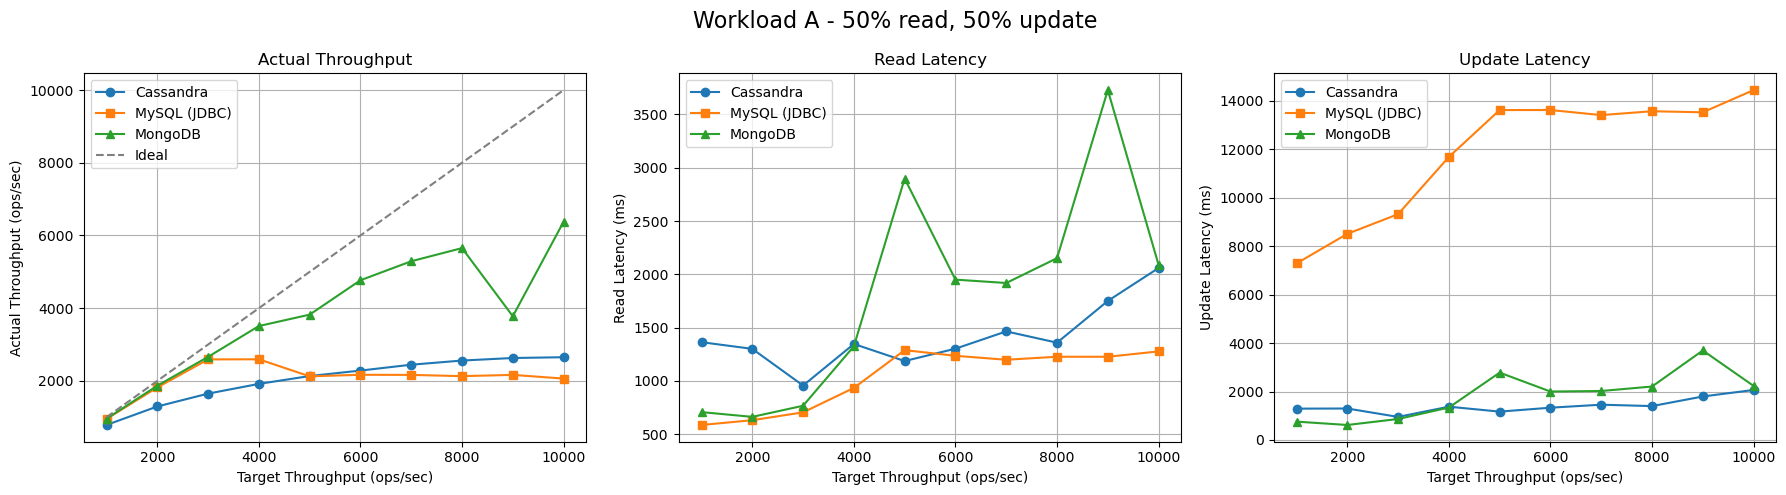

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Actual Throughput vs Target Throughput
axes[0].plot(df_cassandra["Target Throughput"], df_cassandra["Actual Throughput"], marker='o', label="Cassandra")
axes[0].plot(df_jdbc["Target Throughput"], df_jdbc["Actual Throughput"], marker='s', label="MySQL (JDBC)")
axes[0].plot(df_mongo["Target Throughput"], df_mongo["Actual Throughput"], marker='^', label="MongoDB")
axes[0].plot(df_cassandra["Target Throughput"], df_cassandra["Target Throughput"], linestyle='--', color='gray', label="Ideal")
axes[0].set_title("Actual Throughput")
axes[0].set_xlabel("Target Throughput (ops/sec)")
axes[0].set_ylabel("Actual Throughput (ops/sec)")
axes[0].grid(True)
axes[0].legend()

# Plot 2: Read Latency vs Target Throughput
axes[1].plot(df_cassandra["Target Throughput"], df_cassandra["Read Latency (ms)"], marker='o', label="Cassandra")
axes[1].plot(df_jdbc["Target Throughput"], df_jdbc["Read Latency (ms)"], marker='s', label="MySQL (JDBC)")
axes[1].plot(df_mongo["Target Throughput"], df_mongo["Read Latency (ms)"], marker='^', label="MongoDB")
axes[1].set_title("Read Latency")
axes[1].set_xlabel("Target Throughput (ops/sec)")
axes[1].set_ylabel("Read Latency (ms)")
axes[1].grid(True)
axes[1].legend()

# Plot 3: Update Latency vs Target Throughput
axes[2].plot(df_cassandra["Target Throughput"], df_cassandra["Update Latency (ms)"], marker='o', label="Cassandra")
axes[2].plot(df_jdbc["Target Throughput"], df_jdbc["Update Latency (ms)"], marker='s', label="MySQL (JDBC)")
axes[2].plot(df_mongo["Target Throughput"], df_mongo["Update Latency (ms)"], marker='^', label="MongoDB")
axes[2].set_title("Update Latency")
axes[2].set_xlabel("Target Throughput (ops/sec)")
axes[2].set_ylabel("Update Latency (ms)")
axes[2].grid(True)
axes[2].legend()

plt.suptitle("Workload A - 50% read, 50% update", fontsize=16)
plt.tight_layout()
plt.show()

## Workload B - 95% read, 5% update

In [67]:
df_cassandra = pd.read_csv('data/ycsb/ycsb_results_cassandra-cql_workloadb.csv')
df_jdbc = pd.read_csv('data/ycsb/ycsb_results_jdbc_workloadb.csv')
df_mongo = pd.read_csv('data/ycsb/ycsb_results_mongodb_workloadb.csv')

In [68]:
df_cassandra.columns = df_cassandra.columns.str.strip()
df_jdbc.columns = df_jdbc.columns.str.strip()
df_mongo.columns = df_mongo.columns.str.strip()

In [69]:
df_cassandra

,Target Throughput,Actual Throughput,Read Latency (ms),Update Latency (ms)
0,1000,787.091696,943.066167,1066.103053
1,2000,1286.670098,1036.656230,1330.082222
2,3000,1661.681622,1210.516435,1447.212598
3,4000,1884.658877,1768.373878,2121.706994
4,5000,2134.927412,3304.323446,4068.899431
5,6000,2263.467632,2657.653850,3042.590994
6,7000,2295.684114,3050.864737,3668.764000
7,8000,2166.377816,3322.275659,4336.301455
8,9000,2262.955420,3150.023669,3425.987854
9,10000,2654.632333,1624.840957,2006.615234


In [70]:
df_jdbc

,Target Throughput,Actual Throughput,Read Latency (ms),Update Latency (ms)
0,1000,950.479992,453.546507,5881.828629
1,2000,1832.508704,481.359444,5362.408367
2,3000,2598.752599,577.472779,6279.084291
3,4000,3324.468085,636.823109,7272.575000
4,5000,4045.307443,850.597646,9117.666667
5,6000,4019.292605,2496.501736,16880.247465
6,7000,4106.776181,2258.007589,16080.744639
7,8000,4230.118443,2313.561442,15598.731006
8,9000,4045.307443,2485.862712,15804.589391
9,10000,4230.118443,2392.835014,16280.661088


In [71]:
df_mongo

,Target Throughput,Actual Throughput,Read Latency (ms),Update Latency (ms)
0,1000,963.020031,603.966924,1062.141527
1,2000,1837.559721,876.979259,1740.563745
2,3000,2627.430373,1487.742558,2424.300000
3,4000,3393.281303,1635.895818,2485.228797
4,5000,4108.463435,1796.006862,2704.683112
5,6000,4812.319538,1956.662406,2734.031895
6,7000,5279.831045,2137.846801,3082.653226
7,8000,5714.285714,2080.846909,2968.398467
8,9000,5271.481286,2356.868818,2849.484649
9,10000,6056.935191,2177.726500,3495.162393


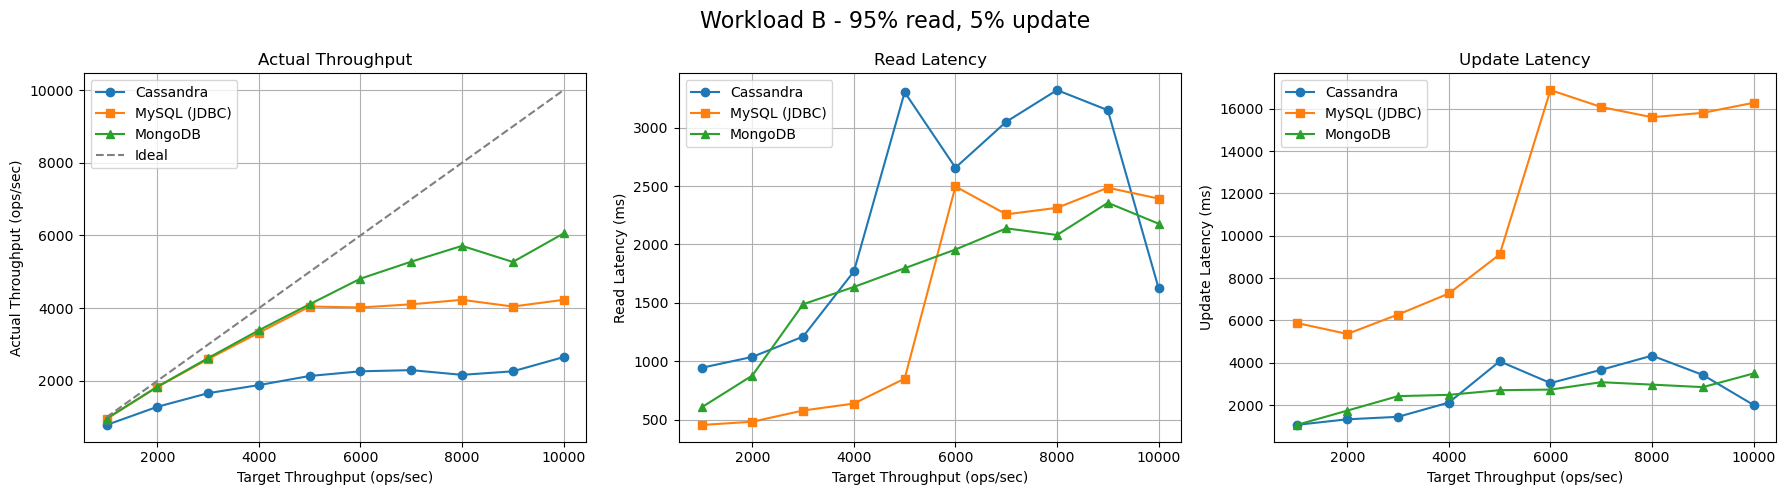

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Actual Throughput vs Target Throughput
axes[0].plot(df_cassandra["Target Throughput"], df_cassandra["Actual Throughput"], marker='o', label="Cassandra")
axes[0].plot(df_jdbc["Target Throughput"], df_jdbc["Actual Throughput"], marker='s', label="MySQL (JDBC)")
axes[0].plot(df_mongo["Target Throughput"], df_mongo["Actual Throughput"], marker='^', label="MongoDB")
axes[0].plot(df_cassandra["Target Throughput"], df_cassandra["Target Throughput"], linestyle='--', color='gray', label="Ideal")
axes[0].set_title("Actual Throughput")
axes[0].set_xlabel("Target Throughput (ops/sec)")
axes[0].set_ylabel("Actual Throughput (ops/sec)")
axes[0].grid(True)
axes[0].legend()

# Plot 2: Read Latency vs Target Throughput
axes[1].plot(df_cassandra["Target Throughput"], df_cassandra["Read Latency (ms)"], marker='o', label="Cassandra")
axes[1].plot(df_jdbc["Target Throughput"], df_jdbc["Read Latency (ms)"], marker='s', label="MySQL (JDBC)")
axes[1].plot(df_mongo["Target Throughput"], df_mongo["Read Latency (ms)"], marker='^', label="MongoDB")
axes[1].set_title("Read Latency")
axes[1].set_xlabel("Target Throughput (ops/sec)")
axes[1].set_ylabel("Read Latency (ms)")
axes[1].grid(True)
axes[1].legend()

# Plot 3: Update Latency vs Target Throughput
axes[2].plot(df_cassandra["Target Throughput"], df_cassandra["Update Latency (ms)"], marker='o', label="Cassandra")
axes[2].plot(df_jdbc["Target Throughput"], df_jdbc["Update Latency (ms)"], marker='s', label="MySQL (JDBC)")
axes[2].plot(df_mongo["Target Throughput"], df_mongo["Update Latency (ms)"], marker='^', label="MongoDB")
axes[2].set_title("Update Latency")
axes[2].set_xlabel("Target Throughput (ops/sec)")
axes[2].set_ylabel("Update Latency (ms)")
axes[2].grid(True)
axes[2].legend()

plt.suptitle("Workload B - 95% read, 5% update", fontsize=16)
plt.tight_layout()
plt.show()

## Workload C - 100% read

In [73]:
df_cassandra = pd.read_csv('data/ycsb/ycsb_results_cassandra-cql_workloadc.csv')
df_jdbc = pd.read_csv('data/ycsb/ycsb_results_jdbc_workloadc.csv')
df_mongo = pd.read_csv('data/ycsb/ycsb_results_mongodb_workloadc.csv')

In [74]:
df_cassandra.columns = df_cassandra.columns.str.strip()
df_jdbc.columns = df_jdbc.columns.str.strip()
df_mongo.columns = df_mongo.columns.str.strip()

In [75]:
df_cassandra

,Target Throughput,Actual Throughput,Read Latency (ms),Update Latency (ms)
0,1000,786.782061,902.7434,
1,2000,1291.322314,982.9210,
2,3000,1654.259719,1015.1968,
3,4000,1926.782274,1077.5681,
4,5000,2139.495079,1583.2112,
5,6000,2288.853285,1389.5891,
6,7000,2418.964683,1469.8483,
7,8000,2556.890821,1823.4978,
8,9000,2658.867323,1861.3813,
9,10000,2721.829069,1525.9742,


In [76]:
df_jdbc

,Target Throughput,Actual Throughput,Read Latency (ms),Update Latency (ms)
0,1000,952.653139,672.4830,
1,2000,1822.489521,523.8887,
2,3000,2594.033722,533.9180,
3,4000,3307.972213,534.6091,
4,5000,3987.240829,595.1781,
5,6000,4528.985507,793.5797,
6,7000,5122.950820,1675.8338,
7,8000,5235.602094,1711.0680,
8,9000,5714.285714,2203.1947,
9,10000,5844.535359,1958.2233,


In [77]:
df_mongo

,Target Throughput,Actual Throughput,Read Latency (ms),Update Latency (ms)
0,1000,942.684766,934.8451,
1,2000,1817.851300,937.9171,
2,3000,2616.431188,1062.1703,
3,4000,3187.759005,1354.1974,
4,5000,4098.360656,1623.5140,
5,6000,4766.444233,2084.6344,
6,7000,4894.762604,2154.4074,
7,8000,5733.944954,2433.9726,
8,9000,5602.240896,1973.6273,
9,10000,5636.978579,2616.4806,


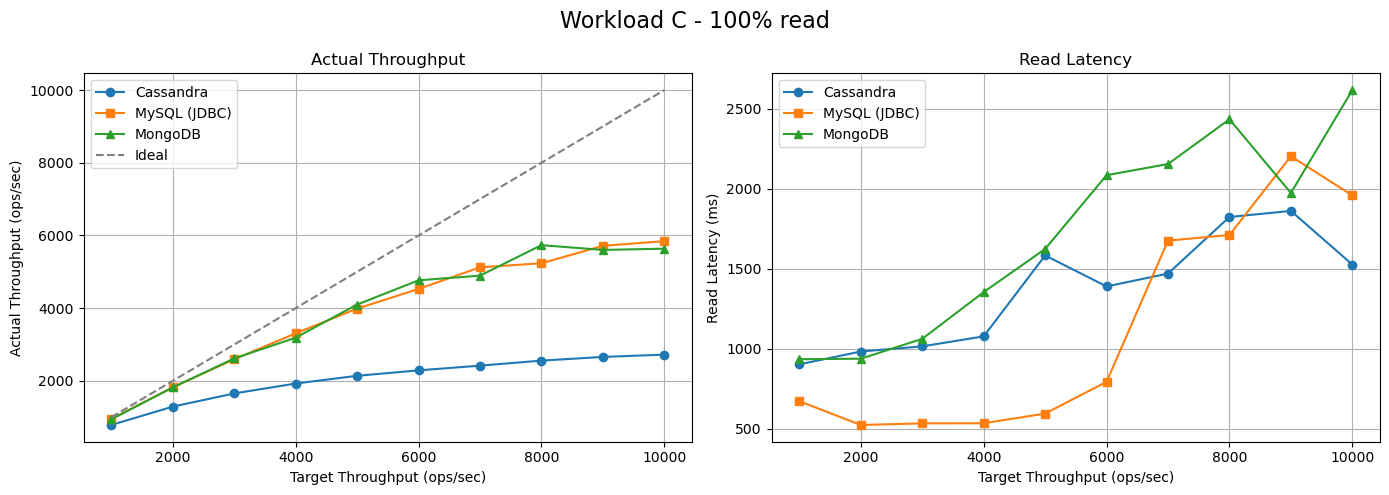

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual Throughput vs Target Throughput
axes[0].plot(df_cassandra["Target Throughput"], df_cassandra["Actual Throughput"], marker='o', label="Cassandra")
axes[0].plot(df_jdbc["Target Throughput"], df_jdbc["Actual Throughput"], marker='s', label="MySQL (JDBC)")
axes[0].plot(df_mongo["Target Throughput"], df_mongo["Actual Throughput"], marker='^', label="MongoDB")
axes[0].plot(df_cassandra["Target Throughput"], df_cassandra["Target Throughput"], linestyle='--', color='gray', label="Ideal")
axes[0].set_title("Actual Throughput")
axes[0].set_xlabel("Target Throughput (ops/sec)")
axes[0].set_ylabel("Actual Throughput (ops/sec)")
axes[0].grid(True)
axes[0].legend()

# Plot 2: Read Latency vs Target Throughput
axes[1].plot(df_cassandra["Target Throughput"], df_cassandra["Read Latency (ms)"], marker='o', label="Cassandra")
axes[1].plot(df_jdbc["Target Throughput"], df_jdbc["Read Latency (ms)"], marker='s', label="MySQL (JDBC)")
axes[1].plot(df_mongo["Target Throughput"], df_mongo["Read Latency (ms)"], marker='^', label="MongoDB")
axes[1].set_title("Read Latency")
axes[1].set_xlabel("Target Throughput (ops/sec)")
axes[1].set_ylabel("Read Latency (ms)")
axes[1].grid(True)
axes[1].legend()


plt.suptitle("Workload C - 100% read", fontsize=16)
plt.tight_layout()
plt.show()

# Streaming

## Kafka Producer

In [ ]:
import json
import time
from datetime import datetime
from kafka import KafkaProducer
import praw
import random

In [ ]:
reddit = praw.Reddit(
    client_id="****************",
    client_secret="****************",
    user_agent="MyRedditStreamer by /u/AntelopeReady507"
)

producer = KafkaProducer(bootstrap_servers="localhost:9092")

topic_name = "reddit-posts"
subreddits = "news+technology"

In [ ]:
print("Fetching 1000 posts from Reddit...")

fetched_posts = []
posts = reddit.subreddit(subreddits).new(limit=1000)

for submission in posts:
    post_data = {
        "subreddit": str(submission.subreddit),
        "title": submission.title,
        "text": submission.selftext,
        "created_utc": submission.created_utc
    }
    fetched_posts.append(post_data)

print(f"Fetched {len(fetched_posts)} posts.")

Fetching 10,000 posts from Reddit...
Fetched 1065 posts.


In [ ]:
print("Starting to stream random number (10 to 50) of posts per minute to Kafka...")

try:
    index = 0
    while index < len(fetched_posts):
        fetch_minute = datetime.now().strftime("%Y-%m-%d %H:%M")

        batch_size = random.randint(10, 50)
        print(f"\n[{fetch_minute}] Sending {batch_size} posts...")

        batch = fetched_posts[index:index+batch_size]
        for post_data in batch:
            post_data['fetch_minute'] = fetch_minute
            message = json.dumps(post_data)
            producer.send(topic_name, message.encode('utf-8'))

        producer.flush()
        print(f"Finished sending posts {index+1} to {index+len(batch)}.")

        index += batch_size
        print("Sleeping for 60 seconds...\n")
        time.sleep(60)

    print("All posts have been sent!")

except KeyboardInterrupt:
    print("Stopped manually.")
finally:
    producer.close()

Starting to stream random number (10 to 50) of posts per minute to Kafka...

[2025-05-07 14:40] Sending 40 posts...
Finished sending posts 1 to 40.
Sleeping for 60 seconds...


[2025-05-07 14:41] Sending 49 posts...
Finished sending posts 41 to 89.
Sleeping for 60 seconds...


[2025-05-07 14:42] Sending 41 posts...
Finished sending posts 90 to 130.
Sleeping for 60 seconds...


[2025-05-07 14:43] Sending 12 posts...
Finished sending posts 131 to 142.
Sleeping for 60 seconds...


[2025-05-07 14:44] Sending 24 posts...
Finished sending posts 143 to 166.
Sleeping for 60 seconds...


[2025-05-07 14:45] Sending 10 posts...
Finished sending posts 167 to 176.
Sleeping for 60 seconds...


[2025-05-07 14:46] Sending 22 posts...
Finished sending posts 177 to 198.
Sleeping for 60 seconds...


[2025-05-07 14:47] Sending 19 posts...
Finished sending posts 199 to 217.
Sleeping for 60 seconds...


[2025-05-07 14:48] Sending 41 posts...
Finished sending posts 218 to 258.
Sleeping for 60 seconds...


[2

## Kafka Consumer

In [ ]:
sc

<SparkContext master=local[*] appName=PySparkShell>

In [ ]:
!pip install --upgrade praw kafka-python vaderSentiment textblob seaborn nltk

In [ ]:
import re
import pandas as pd

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, DoubleType
from pyspark.sql.functions import window

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
stopwords_set = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /home/hduser/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/hduser/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Spark Streaming

In [ ]:
df_kafka = spark.readStream.format("kafka") \
    .option("kafka.bootstrap.servers", "localhost:9092") \
    .option("subscribe", "reddit-posts") \
    .option("startingOffsets", "earliest") \
    .load()

df_kafka = df_kafka.selectExpr("CAST(value AS STRING) AS json_str",
                                   "timestamp")

In [ ]:
!rm -rf /tmp/spark-checkpoint-reddit

In [ ]:
df_kafka.writeStream \
    .format("console") \
    .option("truncate", True) \
    .option("checkpointLocation", "/tmp/spark-checkpoint-reddit") \
    .start()

25/05/07 14:38:47 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


25/05/07 14:38:48 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.


-------------------------------------------
Batch: 0
-------------------------------------------
+--------+---------+
|json_str|timestamp|
+--------+---------+
+--------+---------+



In [ ]:
post_schema = StructType([
    StructField("subreddit", StringType(), True),
    StructField("title", StringType(), True),
    StructField("text", StringType(), True),
    StructField("created_utc", DoubleType(), True),
    StructField("id", StringType(), True)
])

df_kafka = df_kafka.select(F.from_json(F.col("json_str"), post_schema).alias("post"), "timestamp")

df_kafka = df_kafka.select(
    F.col("post.subreddit").alias("subreddit"),
    F.col("post.title").alias("title"),
    F.col("post.text").alias("text"),
    F.col("post.created_utc").alias("created_utc"),
    F.col("timestamp").alias("ingest_ts")
)

In [ ]:
!rm -rf /tmp/spark-checkpoint-reddit

In [ ]:
df_kafka.writeStream \
    .format("console") \
    .option("truncate", True) \
    .option("checkpointLocation", "/tmp/spark-checkpoint-reddit") \
    .start()

25/05/07 14:38:54 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


25/05/07 14:38:54 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.


-------------------------------------------
Batch: 0
-------------------------------------------
+---------+-----+----+-----------+---------+
|subreddit|title|text|created_utc|ingest_ts|
+---------+-----+----+-----------+---------+
+---------+-----+----+-----------+---------+



### Realtime Processing

In [ ]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_compound(text):
    if text is None:
        return 0.0
    score = analyzer.polarity_scores(text)['compound']
    return float(score)

# Sentiment UDF
sentiment_udf = F.udf(get_sentiment_compound, DoubleType())

df_kafka = df_kafka.withColumn("sentiment_score", sentiment_udf(
    F.concat(F.col("title"), F.lit(" "), F.col("text"))
))

df_kafka = df_kafka.withColumn("sentiment_label", 
    F.when(F.col("sentiment_score") >= 0.05, "positive")
     .when(F.col("sentiment_score") <= -0.05, "negative")
     .otherwise("neutral")
)

In [ ]:
# Keyword extraction UDF
def extract_keywords(text):
    if text is None:
        return []

    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^\w\s#@]", " ", text)
    words = text.split()
    keywords = []
    for w in words:
        w_lower = w.lower()
        if len(w_lower) > 2 and w_lower not in stopwords_set:
            if w_lower.startswith("#") or w_lower.startswith("@"):
                keywords.append(w_lower)
            else:
                keywords.append(w_lower)
    return keywords

keywords_udf = F.udf(lambda t: extract_keywords(str(t)), F.ArrayType(StringType()))

posts_enriched_df = df_kafka.withColumn(
    "keywords", keywords_udf(F.concat(F.col("title"), F.lit(" "), F.col("text")))
)

In [ ]:
!rm -rf /tmp/spark-checkpoint-reddit

In [ ]:
console_output_df = posts_enriched_df.select("subreddit", "title", "sentiment_label", "sentiment_score", F.col("keywords").alias("keywords_list"))

console_query = console_output_df.writeStream \
    .outputMode("append") \
    .format("console") \
    .option("truncate", False) \
    .start()

25/05/07 14:38:59 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-101ac2f4-afa9-4d80-b713-e454a6ab59b6. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
25/05/07 14:38:59 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
25/05/07 14:39:00 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.


-------------------------------------------
Batch: 0
-------------------------------------------
+---------+-----+---------------+---------------+-------------+
|subreddit|title|sentiment_label|sentiment_score|keywords_list|
+---------+-----+---------------+---------------+-------------+
+---------+-----+---------------+---------------+-------------+



In [ ]:
!rm -rf /tmp/spark-checkpoint-reddit

### Realtime Aggregations


In [ ]:
# Posts per 1-minute window (by subreddit)
posts_per_min_df = posts_enriched_df.groupBy(
    window(F.col("ingest_ts"), "1 minute"), F.col("subreddit")
).count().alias("post_count")

# Sentiment counts per 1-minute window
sentiment_per_min_df = posts_enriched_df.groupBy(
    window(F.col("ingest_ts"), "1 minute"), F.col("sentiment_label")
).count().alias("count")

# Keyword counts (global count since start)
exploded_keywords_df = posts_enriched_df.select(F.explode(F.col("keywords")).alias("keyword"))
keyword_counts_df = exploded_keywords_df.groupBy(F.col("keyword")).count().alias("count")

In [ ]:
# Write aggregations to memory sinks for visualization
posts_per_min_query = posts_per_min_df.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .queryName("posts_per_minute") \
    .start()

sentiment_per_min_query = sentiment_per_min_df.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .queryName("sentiment_per_minute") \
    .start()

keyword_count_query = keyword_counts_df.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .queryName("keyword_counts") \
    .start()

25/05/07 14:39:03 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-357c8d62-2079-416a-ab8d-b41536f7cb26. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
25/05/07 14:39:03 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
25/05/07 14:39:03 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.
25/05/07 14:39:04 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-2d21f811-35e8-416c-9b18-9e704cae5ef9. If it's required to delete it under any circumstances, please set spark.sql.streamin

### Real-Time Analytics & Visualization


In [ ]:
posts_per_min_df_pandas = spark.sql(
    """
    SELECT 
        CAST(window.start AS STRING) AS start_time,
        CAST(window.end AS STRING) AS end_time,
        subreddit,
        count AS post_count
    FROM 
        posts_per_minute
    ORDER BY 
        window.start
    """
).toPandas()

posts_per_min_df_pandas["start_time"] = pd.to_datetime(posts_per_min_df_pandas["start_time"])
posts_per_min_df_pandas["end_time"] = pd.to_datetime(posts_per_min_df_pandas["end_time"])

posts_per_min_df_pandas.tail()

,start_time,end_time,subreddit,post_count
47,2025-05-07 15:10:00,2025-05-07 15:11:00,technology,42
48,2025-05-07 15:11:00,2025-05-07 15:12:00,technology,46
49,2025-05-07 15:12:00,2025-05-07 15:13:00,technology,25
50,2025-05-07 15:13:00,2025-05-07 15:14:00,technology,43
51,2025-05-07 15:14:00,2025-05-07 15:15:00,technology,9


In [ ]:
sentiment_per_min_df_pandas = spark.sql(
    """
    SELECT 
        CAST(window.start AS STRING) AS start_time,
        sentiment_label,
        count
    FROM 
        sentiment_per_minute
    ORDER BY 
        window.start, sentiment_label
    """
).toPandas()

sentiment_per_min_df_pandas["start_time"] = pd.to_datetime(sentiment_per_min_df_pandas["start_time"])

sentiment_per_min_df_pandas.tail()

,start_time,sentiment_label,count
100,2025-05-07 15:13:00,neutral,21
101,2025-05-07 15:13:00,positive,11
102,2025-05-07 15:14:00,negative,3
103,2025-05-07 15:14:00,neutral,4
104,2025-05-07 15:14:00,positive,2


In [ ]:
sentiment_pivot = sentiment_per_min_df_pandas.pivot(index='start_time', columns='sentiment_label', values='count').fillna(0)
sentiment_pivot = sentiment_pivot.reset_index()
sentiment_pivot.columns.name = None
sentiment_pivot.tail()

,start_time,negative,neutral,positive
30,2025-05-07 15:10:00,17,12,13
31,2025-05-07 15:11:00,16,14,16
32,2025-05-07 15:12:00,8,12,5
33,2025-05-07 15:13:00,11,21,11
34,2025-05-07 15:14:00,3,4,2


In [ ]:
top_keywords_df = spark.sql("SELECT keyword, count FROM keyword_counts ORDER BY count DESC LIMIT 10").toPandas()
print(top_keywords_df)

     keyword  count
0      trump    100
1        new     96
2       says     83
3     google     58
4      china     57
5      apple     55
6       data     50
7  microsoft     42
8        app     40
9       meta     39


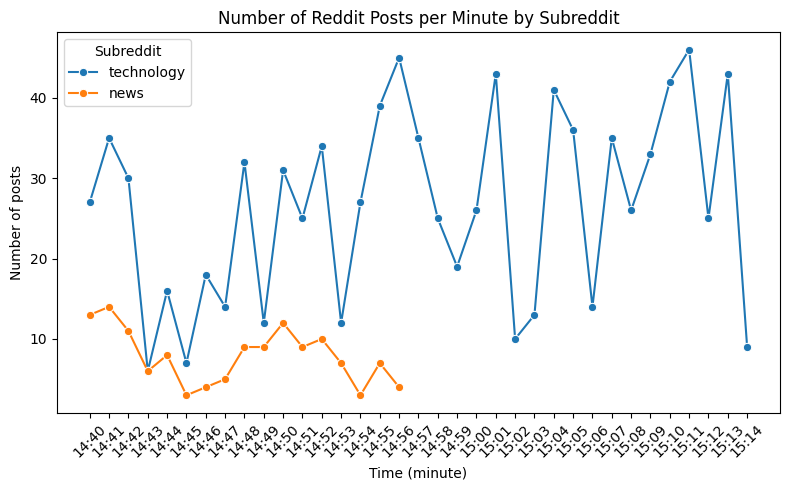

In [ ]:
posts_per_min_df_pandas = posts_per_min_df_pandas.sort_values('start_time')

posts_per_min_df_pandas['minute'] = posts_per_min_df_pandas['start_time'].dt.strftime('%H:%M')

plt.figure(figsize=(8,5))
sns.lineplot(data=posts_per_min_df_pandas, x='minute', y='post_count', hue='subreddit', marker="o")
plt.title("Number of Reddit Posts per Minute by Subreddit")
plt.xlabel("Time (minute)")
plt.ylabel("Number of posts")
plt.xticks(rotation=45)
plt.legend(title='Subreddit')
plt.tight_layout()
plt.show()

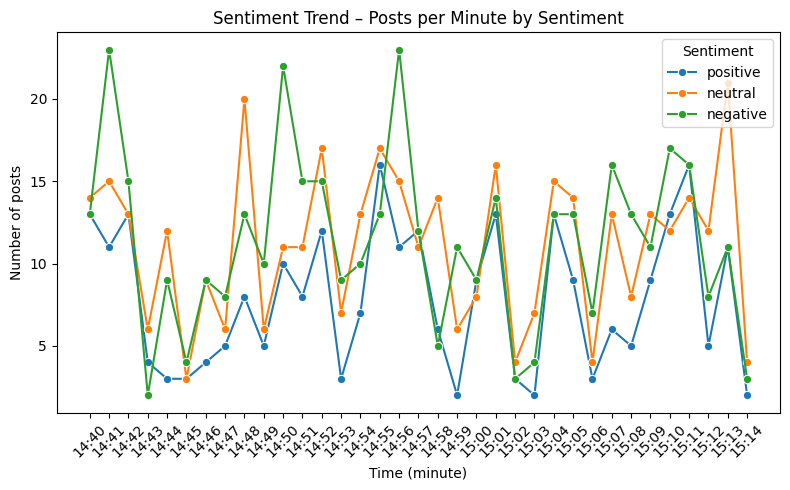

In [ ]:
sentiment_pivot = sentiment_pivot.sort_values('start_time')
sentiment_pivot['minute'] = sentiment_pivot['start_time'].dt.strftime('%H:%M')

plt.figure(figsize=(8,5))
for sentiment in ['positive', 'neutral', 'negative']:
    if sentiment in sentiment_pivot:
        sns.lineplot(data=sentiment_pivot, x='minute', y=sentiment, label=sentiment, marker="o")  # <== marker added
plt.title("Sentiment Trend – Posts per Minute by Sentiment")
plt.xlabel("Time (minute)")
plt.ylabel("Number of posts")
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


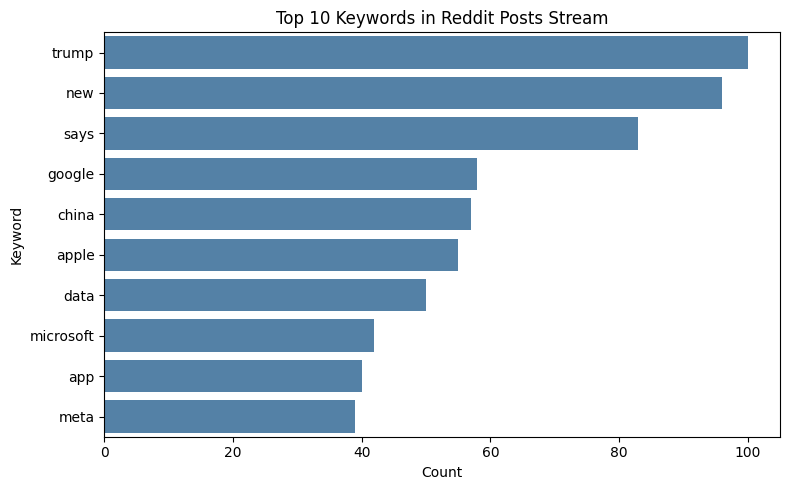

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=top_keywords_df, x='count', y='keyword', color='steelblue')
plt.title("Top 10 Keywords in Reddit Posts Stream")
plt.xlabel("Count")
plt.ylabel("Keyword")
plt.tight_layout()
plt.show()

In [ ]:
# console_query.stop()
# posts_per_min_query.stop()
# sentiment_per_min_query.stop()
# keyword_count_query.stop()
# spark.stop()